## Q5 V-Plot

Total number of unique (X, Y) pairs in the input file: 280653


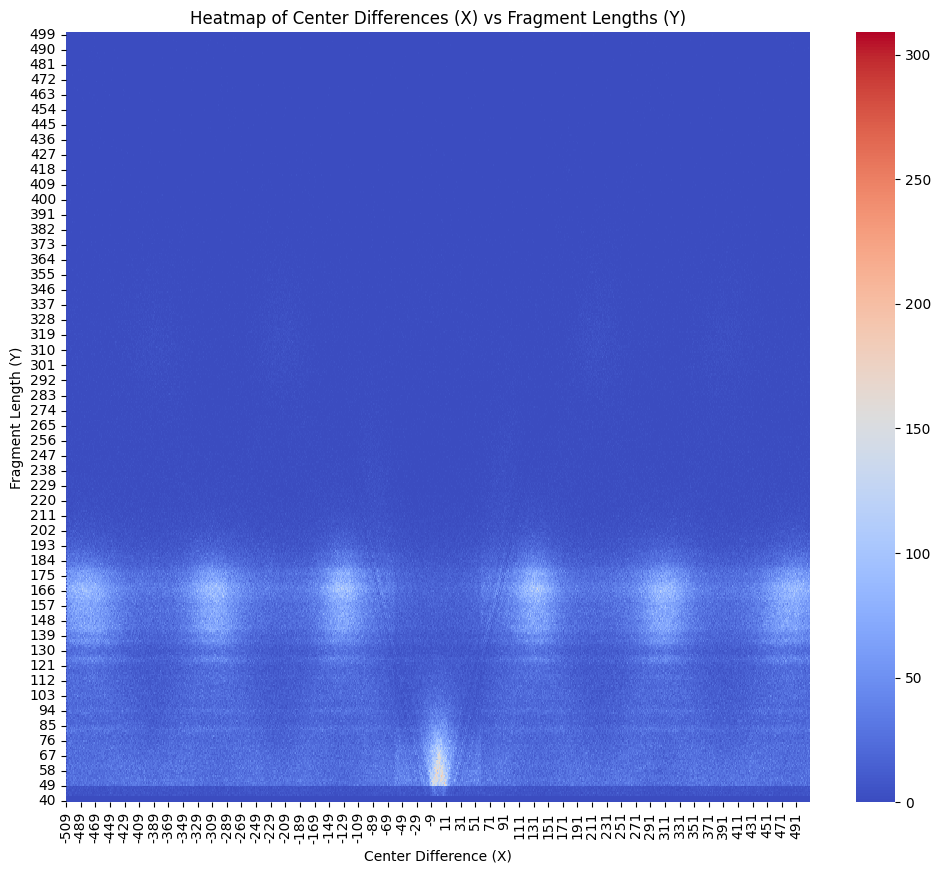

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Counter to store frequency of (center_diff, fragment_length) pairs
frequency_counter = Counter()

# Read and parse the input BED-like file
with open('mapped.bed', 'r') as file:
    for line in file:
        fields = line.strip().split('\t')

        # Compute center positions of both fragments
        fragment1_center = (int(fields[2]) + int(fields[3])) / 2
        fragment2_center = (int(fields[8]) + int(fields[9])) / 2

        # Compute X: difference in center positions
        center_difference = int(fragment2_center - fragment1_center)

        # Compute Y: length of the second fragment
        fragment_length = int(fields[9]) - int(fields[8])

        # Increment count for the (X, Y) pair
        frequency_counter[(center_difference, fragment_length)] += 1

# Report total unique (X, Y) pairs
print("Total number of unique (X, Y) pairs in the input file:", len(frequency_counter))

# Extract sorted unique values for X and Y
unique_center_differences = sorted(set(x for x, y in frequency_counter))
unique_fragment_lengths = sorted(set(y for x, y in frequency_counter))

# Initialize the matrix to hold counts
heatmap_matrix = np.zeros((len(unique_fragment_lengths), len(unique_center_differences)), dtype=int)

# Fill the matrix using the frequency counter
for row_index, length in enumerate(unique_fragment_lengths):
    for col_index, diff in enumerate(unique_center_differences):
        heatmap_matrix[row_index, col_index] = frequency_counter.get((diff, length), 0)

# Convert matrix to a DataFrame for plotting
heatmap_df = pd.DataFrame(heatmap_matrix, index=unique_fragment_lengths, columns=unique_center_differences)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, cmap='coolwarm', annot=False, fmt='d')
plt.gca().invert_yaxis()
plt.title('Heatmap of Center Differences (X) vs Fragment Lengths (Y)')
plt.xlabel('Center Difference (X)')
plt.ylabel('Fragment Length (Y)')
plt.show()
